# Preprocesado de señal para el soft sensor a nivel de minuto

Este notebook se separa de [`ML_Model_Approach_1.ipynb`](./ML_Model_Approach_1.ipynb) (Step 7) para tratar en un solo sitio, con espacio para iterar, tres preguntas que surgieron ahi:

1. ¿Ayuda el postprocesado de señal (eliminación de outliers, suavizado) que ya se probó en [`main.ipynb`](./main.ipynb) a nivel horario, aplicado ahora a nivel de minuto?
2. El Step 7 pasaba de 20 s a minuto **promediando 3 muestras hacia delante** (`t, t+20s, t+40s` para "el minuto k"). Eso mete hasta 40 s de informacion posterior al instante nominal del minuto -- no es la fuga clasica (no toca el target), pero rompe la causalidad que necesitaria un sensor real desplegado en producción.
3. ¿Merece la pena montar un notebook aparte solo para esto? Si -- este.

**Aviso importante antes de invertir tiempo aqui:** `main.ipynb` ya investigó esta misma pregunta -- si el detalle de sensor por debajo de la hora (20 s, minutos, primeros N minutos de la hora) predice mejor que la propia inercia horaria del target -- por varias vías independientes (medias/std/min/max intra-hora, LSTM sobre la secuencia de 20 s, terciles y pendientes, barrido de correlación cruzada a resolución nativa, predicción con los primeros 20 minutos de cada hora). **Ninguna encontró señal utilizable**: el techo está en la escala horaria hacia arriba, no hacia abajo (ver celdas 69-74 de `main.ipynb`). Este notebook comprueba si esa conclusión se sostiene tambien para el pipeline concreto de Step 7 (XGBoost sobre las 6 variables agregadas) una vez limpiamos la señal correctamente -- pero hay que entrar sabiendo que la apuesta de que esto desbloquee mucho mas skill es baja.

In [1]:
import math
import numpy as np
import pandas as pd
import warnings; warnings.simplefilter('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# FEATURES = ['avg_air_flow', 'avg_float_level', '% Iron Feed', 'Amina Flow', 'Ore Pulp Density', 'Ore Pulp pH']
TARGETS = ['% Silica Concentrate', '% Iron Concentrate']

## Carga a resolución nativa (20 s)

In [2]:
STARTUP_END = pd.Timestamp('2017-03-29 11:01:47.998')  # ver main.ipynb, celda 4-5

df = pd.read_csv('../Datasets/MiningProcess_Flotation_Plant_Database.csv', decimal=',')
df['date'] = pd.to_datetime(df['date'])
# index dataset with date
df.set_index('date', inplace=True)

## Detección causal de outliers utilizando cuartiles

In [3]:
numeric_df = df.select_dtypes(include=[np.number])

# #### Whole dataset outlier detection (error si el dataset es estacionario)
# # 3. Calculate Q1, Q3, and IQR for every numeric column
# Q1 = numeric_df.quantile(0.25)
# Q3 = numeric_df.quantile(0.75)
# IQR = Q3 - Q1

# # 4. Calculate the lower and upper bounds
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# # 5. Filter the dataset
# # Create a mask checking if values fall strictly within the allowed bounds
# # .all(axis=1) ensures we only keep the row if ALL its numeric columns are within bounds
# mask = ((numeric_df >= lower_bound) & (numeric_df <= upper_bound)).all(axis=1)

# #### windowed outlier detection using rolling IQR
window_size = 180 # Adjust based on your signal's frequency

# # Calculate rolling quartiles
Q1_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.25)
Q3_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.75)
IQR_rolling = Q3_rolling - Q1_rolling

# Calculate dynamic bounds
lower_bound_rolling = Q1_rolling - 1.5 * IQR_rolling
upper_bound_rolling = Q3_rolling + 1.5 * IQR_rolling

# Filter the dataset
mask = ((numeric_df >= lower_bound_rolling) & (numeric_df <= upper_bound_rolling)).all(axis=1)
df_cleaned = df[mask]

print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_cleaned)}")

Original row count: 737453
Cleaned row count: 529287


In [4]:
# # Outlier removal visualization
# # Assuming df and df_cleaned are already created from the previous step

# # Select only the numeric columns for plotting
# numeric_cols = df.select_dtypes(include=[np.number]).columns

# # Iterate over each numeric column to generate the comparison plots
# for col in numeric_cols:
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
#     # --- Plot 1: Time Series (Index vs Value) ---
#     # Plot original data (red) with outliers visible
#     axes[0].plot(df.index, df[col], label='Original (with Outliers)', 
#                  color='lightcoral', marker='o', linestyle='-')
    
#     # Plot cleaned data (blue) over it to show what remains
#     axes[0].plot(df_cleaned.index, df_cleaned[col], label='Cleaned', 
#                  color='dodgerblue', marker='.', linestyle='-')
    
#     axes[0].set_title(f'Time Series: {col}')
#     axes[0].set_xlabel('Index (Time)')
#     axes[0].set_ylabel('Value')
#     axes[0].legend()
#     axes[0].grid(True, alpha=0.3)
    
#     # --- Plot 2: Boxplot ---
#     # Combine original and cleaned data into a temporary DataFrame for seaborn
#     plot_data = pd.DataFrame({
#         'Value': pd.concat([df[col], df_cleaned[col]]),
#         'Dataset': ['Original'] * len(df) + ['Cleaned'] * len(df_cleaned)
#     })
    
#     # Generate side-by-side boxplots
#     sns.boxplot(x='Dataset', y='Value', data=plot_data, ax=axes[1], 
#                 palette=['lightcoral', 'dodgerblue'])
    
#     axes[1].set_title(f'Boxplot: {col}')
#     axes[1].grid(True, alpha=0.3)
    
#     # Adjust layout and display
#     plt.tight_layout()
#     plt.show()

# Decimate to 2 minutes and remove the first times of the dataset

In [5]:
# --- 1. Fix the Time Index (The Crucial Step) ---
# df.groupby(level=0).cumcount() counts the position of each duplicate (0 to 179)
# We multiply that position by 20 seconds and add it to the base timestamp
time_offsets = pd.to_timedelta(df.groupby(level=0).cumcount() * 20, unit='s')

# Overwrite the old, stacked index with the new, mathematically precise timeline
df.index = df.index + time_offsets

# --- 2. Filter the Bad Range ---
start_remove = '2017-03-10 01:00:00'
end_remove = '2017-03-29 11:01:00'

# Create mask and apply it
mask = (df.index < start_remove) | (df.index > end_remove)
df_filtered = df[mask]

# --- 3. Decimate to 2 Minutes ---
# Now that every row has a precise 20s timestamp, resample will work correctly
df_decimated = df_filtered.resample('2min').mean()

# Drop the empty 19-day gap created by resampling
df_decimated = df_decimated.dropna()

# Correlation map

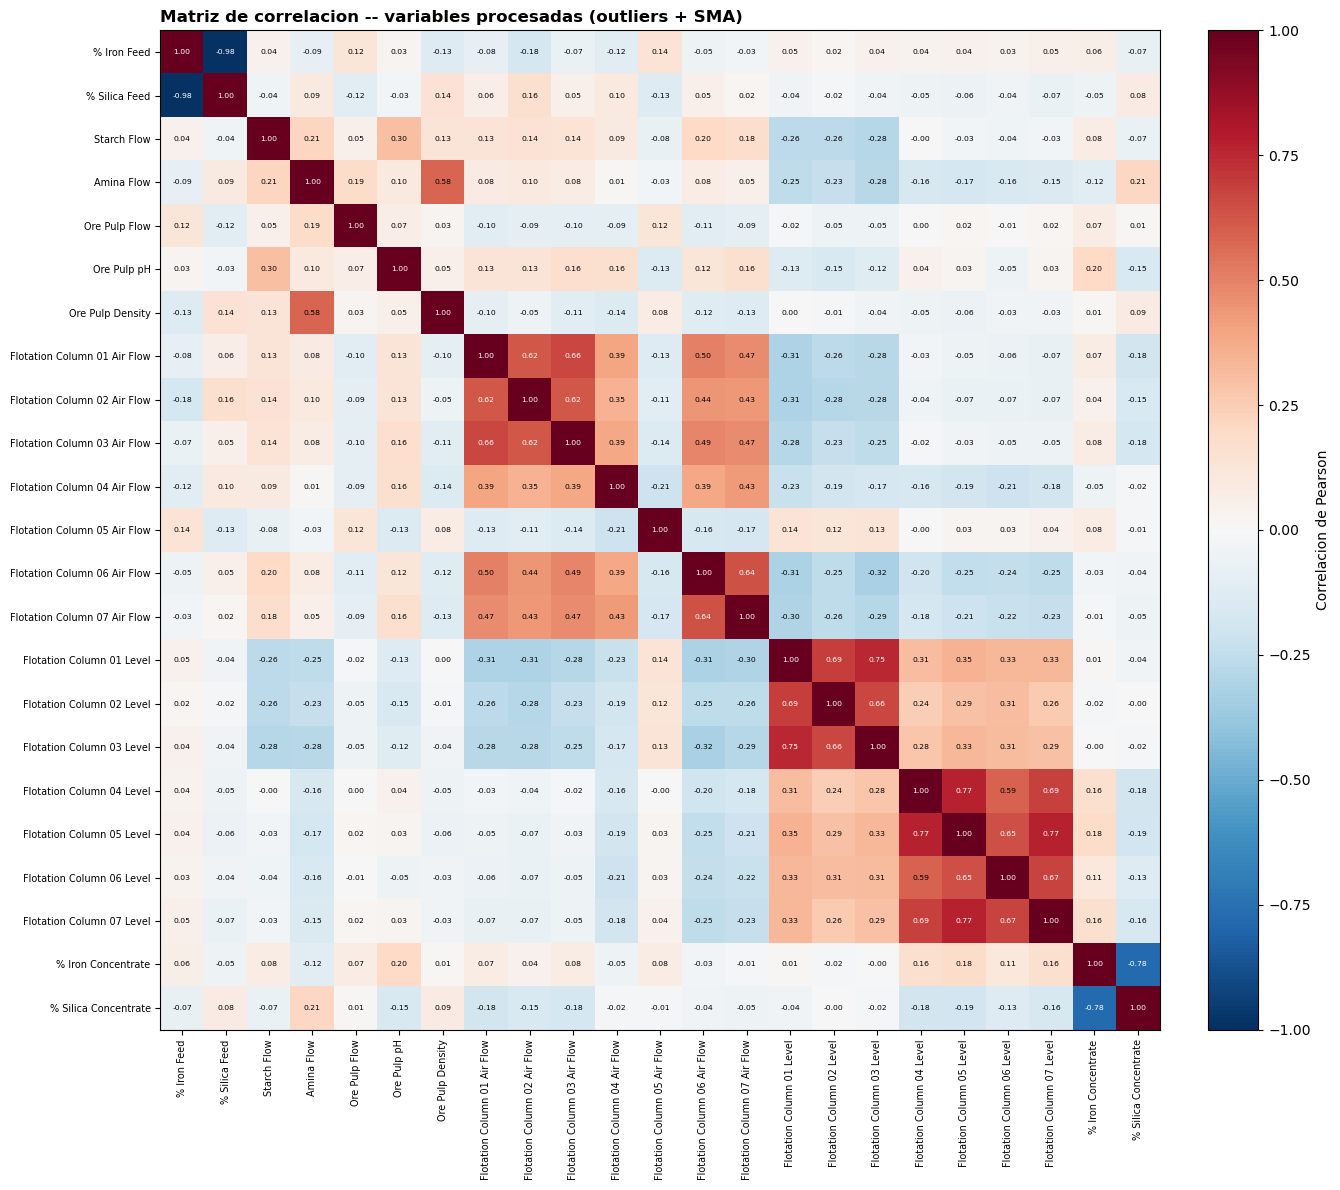

In [6]:
dataset_to_plot_corr = df.copy()  # Create a copy for correlation plotting

corr_matrix = dataset_to_plot_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(dataset_to_plot_corr.columns)))
ax.set_yticks(range(len(dataset_to_plot_corr.columns)))
ax.set_xticklabels(dataset_to_plot_corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(dataset_to_plot_corr.columns, fontsize=7)

for i in range(len(dataset_to_plot_corr.columns)):
    for j in range(len(dataset_to_plot_corr.columns)):
        value = corr_matrix.values[i, j]
        color = 'white' if abs(value) > 0.6 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=5.5, color=color)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlacion de Pearson')
ax.set_title('Matriz de correlacion -- variables procesadas (outliers + SMA)', loc='left', fontweight='bold')

plt.tight_layout()
plt.show()


# Adding seasonal variables: hour, day, month, 

In [7]:
df_decimated['hour'] = df_decimated.index.hour           # Returns 0 to 23
df_decimated['day_of_week'] = df_decimated.index.dayofweek # Returns 0 (Monday) to 6 (Sunday)
df_decimated['month'] = df_decimated.index.month         # Returns 1 (January) to 12 (December)
print(df_decimated.head())

                     % Iron Feed  % Silica Feed  Starch Flow  Amina Flow  \
2017-03-29 12:00:00        60.18           9.34  2015.023333  357.857167   
2017-03-29 12:02:00        60.18           9.34  2003.470000  368.381833   
2017-03-29 12:04:00        60.18           9.34  2001.906667  374.960833   
2017-03-29 12:06:00        60.18           9.34  1858.201667  386.171833   
2017-03-29 12:08:00        60.18           9.34   215.922500  394.077000   

                     Ore Pulp Flow  Ore Pulp pH  Ore Pulp Density  \
2017-03-29 12:00:00     402.541667     9.735155          1.634198   
2017-03-29 12:02:00     401.079833     9.709025          1.597116   
2017-03-29 12:04:00     400.381833     9.682895          1.560033   
2017-03-29 12:06:00     401.543667     9.656833          1.526800   
2017-03-29 12:08:00     400.659500     9.632993          1.528220   

                     Flotation Column 01 Air Flow  \
2017-03-29 12:00:00                    199.820167   
2017-03-29 12:02:00   

# Average variables which are very similar

In [8]:
air_flow_6_7 = [
    'Flotation Column 06 Air Flow', 
    'Flotation Column 07 Air Flow'
]

air_flow_1_2_3 = [
    'Flotation Column 01 Air Flow', 
    'Flotation Column 02 Air Flow', 
    'Flotation Column 03 Air Flow'
]

silica_iron_feed = [
    '% Iron Feed',  
    '% Silica Feed'
]

level_4_5_6_7 = [
    'Flotation Column 04 Level',  
    'Flotation Column 05 Level',
    'Flotation Column 06 Level',  
    'Flotation Column 07 Level'
]

level_1_2_3 = [
    'Flotation Column 01 Level',  
    'Flotation Column 02 Level',
    'Flotation Column 03 Level'
]

# Calculate the row-wise mean for each group and assign to new columns
df_decimated['Air Flow 6_7_Mean'] = df_decimated[air_flow_6_7].mean(axis=1)
df_decimated['Air Flow 1_2_3_Mean'] = df_decimated[air_flow_1_2_3].mean(axis=1)
df_decimated['Feed Iron_Silica_Mean'] = df_decimated[silica_iron_feed].mean(axis=1)
df_decimated['Level 4_5_6_7_Mean'] = df_decimated[level_4_5_6_7].mean(axis=1)
df_decimated['Level 1_2_3_Mean'] = df_decimated[level_1_2_3].mean(axis=1)

# Combine the lists and drop the original features
columns_to_drop = air_flow_6_7 + air_flow_1_2_3 + silica_iron_feed + level_4_5_6_7 + level_1_2_3
df_decimated = df_decimated.drop(columns=columns_to_drop)

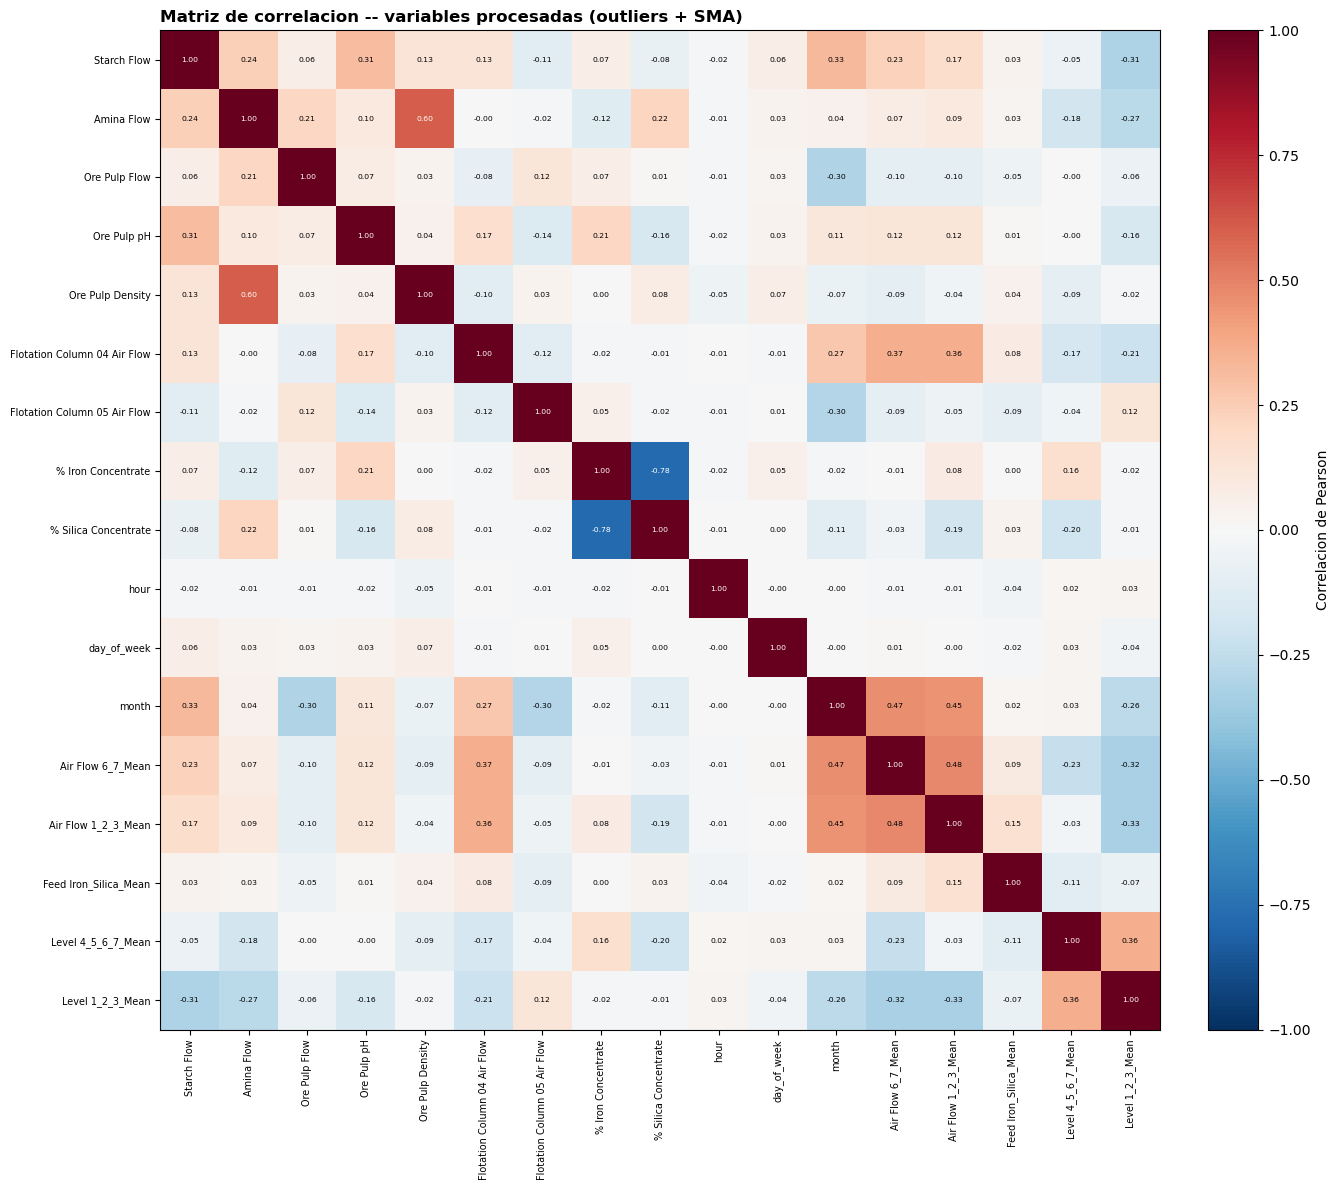

In [9]:
#Correlation matrix incluying seasonal variables
dataset_to_plot_corr = df_decimated.copy()  # Create a copy for correlation plotting

corr_matrix = dataset_to_plot_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(dataset_to_plot_corr.columns)))
ax.set_yticks(range(len(dataset_to_plot_corr.columns)))
ax.set_xticklabels(dataset_to_plot_corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(dataset_to_plot_corr.columns, fontsize=7)

for i in range(len(dataset_to_plot_corr.columns)):
    for j in range(len(dataset_to_plot_corr.columns)):
        value = corr_matrix.values[i, j]
        color = 'white' if abs(value) > 0.6 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=5.5, color=color)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlacion de Pearson')
ax.set_title('Matriz de correlacion -- variables procesadas (outliers + SMA)', loc='left', fontweight='bold')

plt.tight_layout()
plt.show()


# Prepare xgboost training

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor

# Features = everything except the targets (TARGETS defined above)
FEATURE_COLS = [c for c in df_decimated.columns if c not in TARGETS]

X = df_decimated[FEATURE_COLS]
y = df_decimated[TARGETS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=21
)

# z-score normalization: z = (x - mu) / sigma, fit on train only to avoid leakage
X_mean, X_std = X_train.mean(), X_train.std()
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

xgb_params = dict(
    n_estimators=250,
    max_depth=20,
    learning_rate=0.01,
    random_state=21,
)

model = MultiOutputRegressor(XGBRegressor(**xgb_params, n_jobs=-1, tree_method='hist'))
model.fit(X_train_scaled, y_train)

print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)


Train shape: (82908, 15)  Test shape: (35532, 15)


## Busqueda manual (con progreso en tiempo real) sobre los hiperparametros de XGBoost

Busca alrededor de los tres hiperparametros ya fijados en `xgb_params` (`n_estimators`, `max_depth`, `learning_rate`), cuatro valores cada uno -- el que ya se usaba mas tres nuevos en un rango razonable para XGBoost (no simplemente vecinos numericos de `max_depth=20`, que es muy profundo para lo habitual en boosting y sobreajusta facil):

- `n_estimators`: 100, **250**, 400, 600
- `max_depth`: 4, 6, 10, **20** -- rango 4-10 es el habitual; se mantiene 20 porque es el valor actual
- `learning_rate`: 0.005, **0.01**, 0.05, 0.1

**Por que no `GridSearchCV`/`RandomizedSearchCV`:** se probaron los dos y ninguno termino a tiempo en esta maquina (12 nucleos) -- la malla completa (384 ajustes) no acabo en 30 min, y una muestra de 20 combinaciones (120 ajustes) tampoco en 15 min. El coste no es de paralelismo: `max_depth=20` combinado con `n_estimators=600` sobre ~83k filas hace que los ajustes mas caros de la malla dominen el tiempo total, y ambos metodos son una caja negra hasta que `.fit()` termina del todo -- sin forma de ver el progreso ni el mejor resultado parcial mientras corren.

**Que hace esta celda en su lugar:** un bucle manual sobre `ParameterSampler` (mismo mecanismo interno de `RandomizedSearchCV`) que evalua una combinacion cada vez con `cross_val_score` y va imprimiendo, tras cada una, la mejor combinacion y metrica encontradas HASTA ESE MOMENTO. Se puede parar el kernel en cualquier momento (por ejemplo tras las primeras N) y `best_xgb_params`/`best_score` ya tienen el mejor resultado visto hasta ahi -- no hay que esperar a que termine toda la busqueda para tener un resultado usable, ni quedarse a ciegas mientras corre.

In [11]:
from sklearn.model_selection import ParameterSampler, KFold
import time

xgb_param_grid = {
    'n_estimators': [100, 250, 400, 600],
    'max_depth': [4, 6, 10, 20],
    'learning_rate': [0.005, 0.01, 0.05, 0.1],
}

# Numero de combinaciones a probar. No hace falta poner esto muy alto: al
# imprimir el mejor resultado tras CADA combinacion, se puede interrumpir el
# kernel en cualquier momento (Kernel > Interrupt) sin perder el progreso --
# best_xgb_params ya tiene la mejor combinacion vista hasta ese punto.
N_ITER_SEARCH = 20
N_SPLITS = 3

kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=21)
candidates = list(ParameterSampler(xgb_param_grid, n_iter=N_ITER_SEARCH, random_state=21))

best_score = None          # neg_mean_squared_error medio (mayor es mejor, igual criterio que GridSearchCV)
best_xgb_params = None
search_log = []            # una fila por combinacion probada, para inspeccionar luego

print(f'Probando {len(candidates)} combinaciones x {N_SPLITS} folds x {len(TARGETS)} targets...\n')

for i, params in enumerate(candidates, start=1):
    t0 = time.time()
    fold_rmses = []
    for train_idx, val_idx in kfold.split(X_train_scaled):
        Xtr, Xval = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
        ytr, yval = y_train.iloc[train_idx], y_train.iloc[val_idx]

        fold_model = MultiOutputRegressor(
            XGBRegressor(**params, random_state=21, n_jobs=-1, tree_method='hist'))
        fold_model.fit(Xtr, ytr)
        yval_pred = pd.DataFrame(fold_model.predict(Xval), columns=TARGETS, index=Xval.index)

        # RMSE medio entre los dos targets, mismo criterio que metrics_df mas abajo
        rmse_targets = [np.sqrt(mean_squared_error(yval[t], yval_pred[t])) for t in TARGETS]
        fold_rmses.append(np.mean(rmse_targets))

    mean_rmse = float(np.mean(fold_rmses))
    score = -mean_rmse   # neg_mean_squared_error-style: mayor es mejor
    elapsed = time.time() - t0
    search_log.append({**params, 'rmse_cv': mean_rmse, 'segundos': round(elapsed, 1)})

    is_best = best_score is None or score > best_score
    if is_best:
        best_score = score
        best_xgb_params = dict(params)
        best_xgb_params['random_state'] = 21

    # Progreso en tiempo real: la mejor combinacion HASTA AHORA, no solo al terminar.
    marker = ' <-- nueva mejor' if is_best else ''
    print(f'[{i}/{len(candidates)}] {params} -> RMSE cv={mean_rmse:.4f} '
         f'({elapsed:.1f}s){marker}')
    print(f'    Mejor hasta ahora: {best_xgb_params}  (RMSE cv={-best_score:.4f})')

search_log_df = pd.DataFrame(search_log).sort_values('rmse_cv').reset_index(drop=True)

print('\n--- Busqueda terminada ---')
print(f'Mejor combinacion: {best_xgb_params}')
print(f'Mejor RMSE cv: {-best_score:.4f}')
print(f'xgb_params actual: {xgb_params}')
search_log_df


Probando 20 combinaciones x 3 folds x 2 targets...

[1/20] {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.01} -> RMSE cv=0.7189 (18.6s) <-- nueva mejor
    Mejor hasta ahora: {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.01, 'random_state': 21}  (RMSE cv=0.7189)
[2/20] {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1} -> RMSE cv=0.6400 (3.7s) <-- nueva mejor
    Mejor hasta ahora: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 21}  (RMSE cv=0.6400)
[3/20] {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.01} -> RMSE cv=0.9357 (5.9s)
    Mejor hasta ahora: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 21}  (RMSE cv=0.6400)
[4/20] {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.01} -> RMSE cv=0.7679 (13.3s)
    Mejor hasta ahora: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'random_state': 21}  (RMSE cv=0.6400)
[5/20] {'n_estimators': 400, 'max_depth': 4, 'learning_rat

,n_estimators,max_depth,learning_rate,rmse_cv,segundos
0,100,20,0.100,0.294292,248.2
1,600,20,0.010,0.294446,1198.3
2,400,20,0.010,0.302808,631.3
3,400,20,0.005,0.369141,565.2
4,400,10,0.010,0.478553,43.8
5,250,6,0.100,0.510170,7.9
6,600,10,0.005,0.521717,71.2
7,100,20,0.010,0.545463,141.9
8,250,10,0.010,0.556007,30.6
9,100,6,0.100,0.639980,3.7


## Feature importance, metricas y scatter plots de prediccion vs real

                 target    RMSE      R2
0  % Silica Concentrate  0.2809  0.9377
1    % Iron Concentrate  0.2808  0.9364


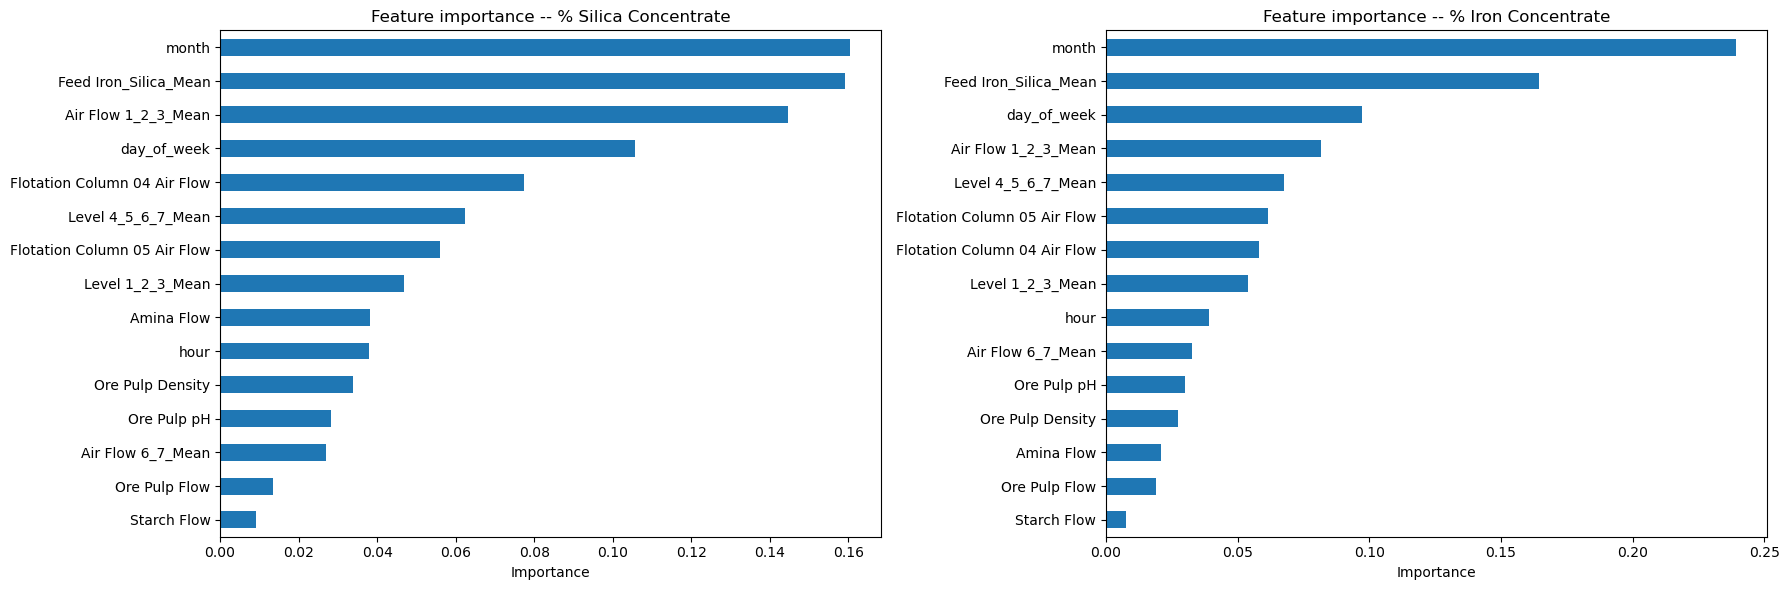

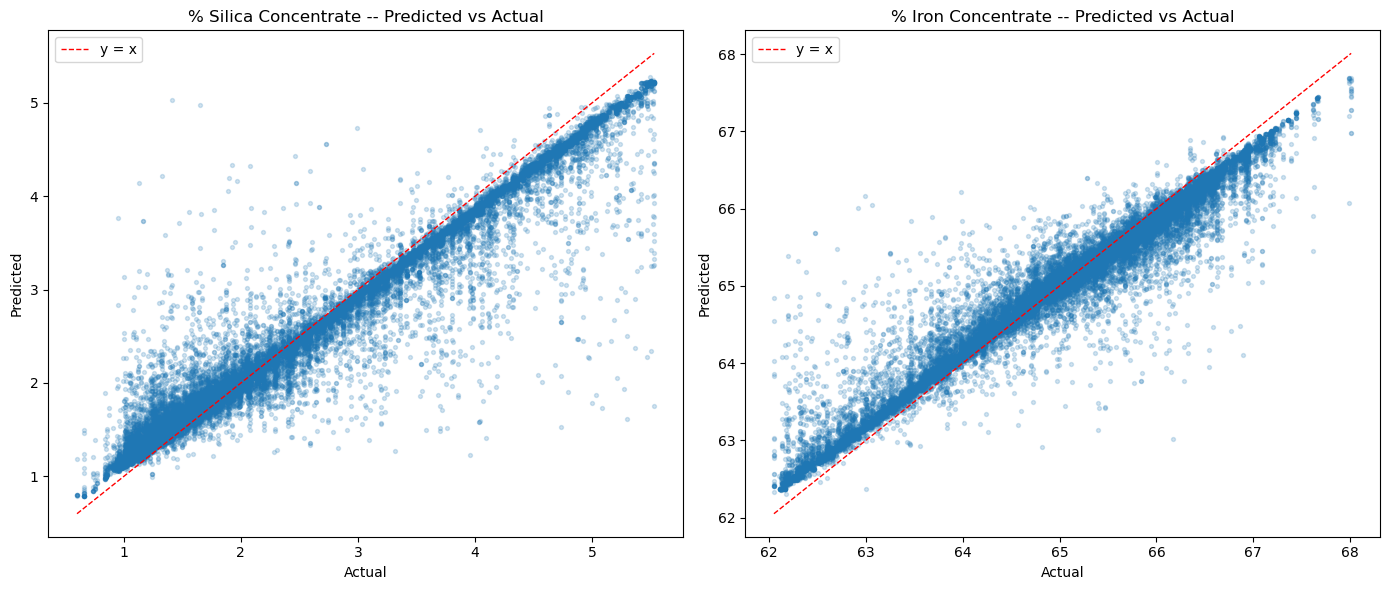

In [12]:
y_pred = pd.DataFrame(model.predict(X_test_scaled), columns=TARGETS, index=X_test.index)

# --- Metrics per target ---
metrics_rows = []
for target in TARGETS:
    rmse = np.sqrt(mean_squared_error(y_test[target], y_pred[target]))
    r2 = r2_score(y_test[target], y_pred[target])
    metrics_rows.append({'target': target, 'RMSE': round(rmse, 4), 'R2': round(r2, 4)})
metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df)

# --- Feature importance per target (one underlying XGBRegressor per target) ---
fig, axes = plt.subplots(1, len(TARGETS), figsize=(9 * len(TARGETS), 6))
for ax, target, estimator in zip(axes, TARGETS, model.estimators_):
    importances = pd.Series(estimator.feature_importances_, index=FEATURE_COLS).sort_values()
    importances.plot(kind='barh', ax=ax)
    ax.set_title(f'Feature importance -- {target}')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# --- Residual / scatter plots: predicted vs actual ---
fig, axes = plt.subplots(1, len(TARGETS), figsize=(7 * len(TARGETS), 6))
for ax, target in zip(axes, TARGETS):
    ax.scatter(y_test[target], y_pred[target], alpha=0.2, s=8)
    lims = [min(y_test[target].min(), y_pred[target].min()),
            max(y_test[target].max(), y_pred[target].max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='y = x')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{target} -- Predicted vs Actual')
    ax.legend()
plt.tight_layout()
plt.show()


## Comparacion con baseline naive (persistencia) y señal de test

In [13]:
# Naive baseline: persistence -- predict each row with the last known actual value
# in time order (shift by 1 on the full, time-sorted series), then align to the
# same test rows the model was evaluated on.
persistence_full = df_decimated[TARGETS].shift(1)
y_pred_naive = persistence_full.loc[y_test.index]

# drop rows where persistence has no prior value (first row of the campaign)
valid_naive = y_pred_naive.dropna().index

metrics_compare_rows = []
for target in TARGETS:
    rmse_model = np.sqrt(mean_squared_error(y_test[target], y_pred[target]))
    r2_model = r2_score(y_test[target], y_pred[target])

    rmse_naive = np.sqrt(mean_squared_error(y_test.loc[valid_naive, target], y_pred_naive.loc[valid_naive, target]))
    r2_naive = r2_score(y_test.loc[valid_naive, target], y_pred_naive.loc[valid_naive, target])

    mejora_pct = 100 * (rmse_naive - rmse_model) / rmse_naive

    metrics_compare_rows.append({
        'target': target,
        'rmse_xgboost': round(rmse_model, 4),
        'r2_xgboost': round(r2_model, 4),
        'rmse_persistencia': round(rmse_naive, 4),
        'r2_persistencia': round(r2_naive, 4),
        'mejora_pct_vs_persistencia': round(mejora_pct, 2),
    })

metrics_compare_df = pd.DataFrame(metrics_compare_rows)
metrics_compare_df


,target,rmse_xgboost,r2_xgboost,rmse_persistencia,r2_persistencia,mejora_pct_vs_persistencia
0,% Silica Concentrate,0.2809,0.9377,0.1411,0.9843,-99.13
1,% Iron Concentrate,0.2808,0.9364,0.1455,0.9829,-92.94


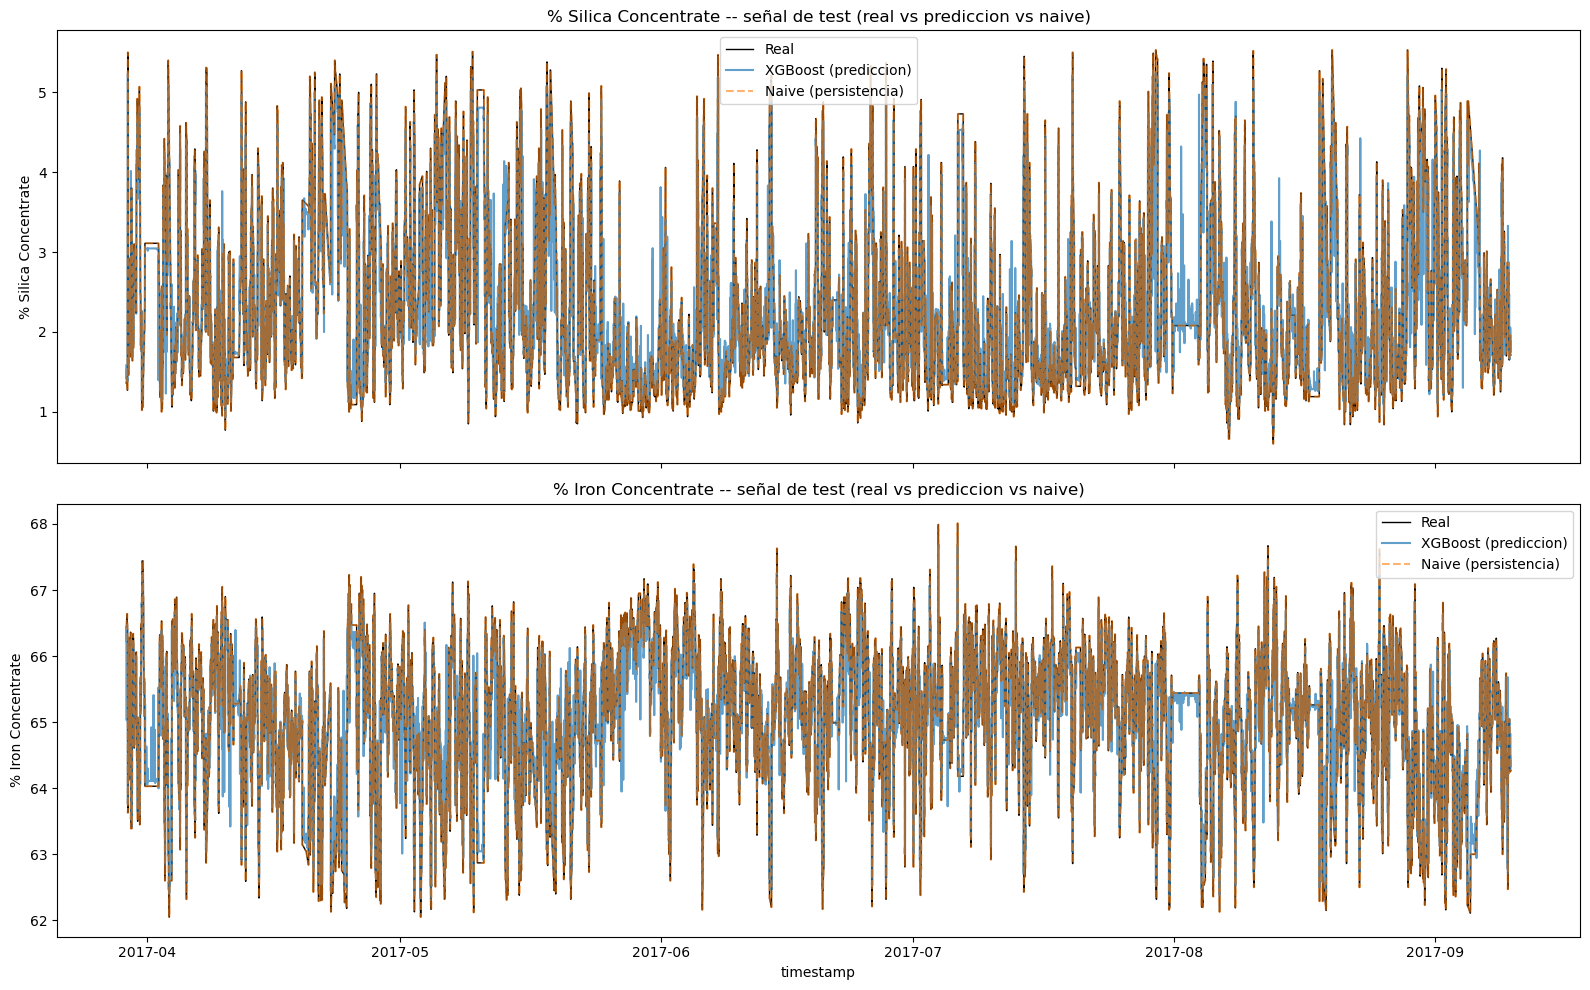

In [14]:
# Test signal plot: real vs predicted vs naive, sorted in time order.
# X_test/y_test come from a random 70/30 split, so the test index is scattered
# across the whole campaign -- sort by timestamp so the lines are readable.
plot_index = y_test.index.sort_values()

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(16, 5 * len(TARGETS)), sharex=True)
if len(TARGETS) == 1:
    axes = [axes]

for ax, target in zip(axes, TARGETS):
    ax.plot(plot_index, y_test.loc[plot_index, target], label='Real', color='black', linewidth=1)
    ax.plot(plot_index, y_pred.loc[plot_index, target], label='XGBoost (prediccion)', alpha=0.7)
    ax.plot(persistence_full.loc[plot_index, target], label='Naive (persistencia)', alpha=0.6, linestyle='--')
    ax.set_title(f'{target} -- señal de test (real vs prediccion vs naive)')
    ax.set_ylabel(target)
    ax.legend()

axes[-1].set_xlabel('timestamp')
plt.tight_layout()
plt.show()


## Registrar el experimento (features, hiperparametros, metricas) en experimentos.csv

Mismo esquema de columnas que usa `ML_Model_Approach_1.ipynb`, para poder comparar experimentos entre notebooks. Una fila de persistencia y una de XGBoost por cada target.

In [15]:
import json
import os
from datetime import datetime

TIME_SERIES_RESULTS_PATH = 'time_series_results.csv'
# store in that csv six signals: real, predicted and naive for each of the two targets

run_timestamp = datetime.now().isoformat(timespec='seconds')

# Formato ancho: una fila por timestamp de muestra, con una columna real/predicted/naive
# por cada target (6 columnas de señal en total). El formato largo anterior (una fila
# por target, apilando primero todo Silica y luego todo Iron) rompe cualquier lector de
# series temporales que trate el CSV como una unica señal por indice de fila: al pasar
# del bloque de Silica (rango ~0-4) al de Iron (rango ~60-70) aparece un escalon
# artificial -- el "cuadrado con 2 periodos" que se ve al releer el fichero, uno por
# cada target apilado. En formato ancho cada columna es una señal real e independiente,
# ya alineada por timestamp, sin ese salto de escala entre bloques.
idx = plot_index  # y_test.index ordenado en el tiempo (celda anterior)

ts_df = pd.DataFrame({'run_timestamp': run_timestamp, 'timestamp': idx})
for target in TARGETS:
    slug = target.replace('% ', '').replace(' ', '_').lower()
    ts_df[f'{slug}_real'] = y_test.loc[idx, target].to_numpy()
    ts_df[f'{slug}_predicted'] = y_pred.loc[idx, target].to_numpy()
    ts_df[f'{slug}_naive'] = persistence_full.loc[idx, target].to_numpy()

file_exists_ts = os.path.exists(TIME_SERIES_RESULTS_PATH)
ts_df.to_csv(TIME_SERIES_RESULTS_PATH, mode='a', header=not file_exists_ts, index=False)

print(f'Registradas {len(ts_df)} filas en {TIME_SERIES_RESULTS_PATH}')


EXPERIMENTOS_PATH = 'experimentos.csv'

train_desde, train_hasta = X_train.index.min(), X_train.index.max()
test_desde, test_hasta = X_test.index.min(), X_test.index.max()

log_rows = []
for target in TARGETS:
    rmse_naive = metrics_compare_df.loc[metrics_compare_df['target'] == target, 'rmse_persistencia'].iloc[0]
    r2_naive = metrics_compare_df.loc[metrics_compare_df['target'] == target, 'r2_persistencia'].iloc[0]
    rmse_model = metrics_compare_df.loc[metrics_compare_df['target'] == target, 'rmse_xgboost'].iloc[0]

    # persistence row
    log_rows.append({
        'timestamp': run_timestamp,
        'horizonte_h': None,
        'modelo': 'Persistencia',
        'n_features': 0,
        'features': json.dumps([]),
        'hiperparametros': json.dumps({}),
        'train_desde': train_desde, 'train_hasta': train_hasta,
        'test_desde': test_desde, 'test_hasta': test_hasta,
        'rmse': rmse_naive, 'r2': r2_naive,
        'rmse_persistencia': rmse_naive, 'mejora_pct': 0.0,
        'notas': f'target={target}; Signal_Preprocessing_Minute_SoftSensor.ipynb, split aleatorio 70/30, resolucion 2min',
    })

    # xgboost row
    log_rows.append({
        'timestamp': run_timestamp,
        'horizonte_h': None,
        'modelo': 'XGBoost (MultiOutputRegressor, z-score)',
        'n_features': len(FEATURE_COLS),
        'features': json.dumps(FEATURE_COLS, ensure_ascii=False),
        'hiperparametros': json.dumps(xgb_params),
        'train_desde': train_desde, 'train_hasta': train_hasta,
        'test_desde': test_desde, 'test_hasta': test_hasta,
        'rmse': rmse_model,
        'r2': metrics_compare_df.loc[metrics_compare_df['target'] == target, 'r2_xgboost'].iloc[0],
        'rmse_persistencia': rmse_naive,
        'mejora_pct': metrics_compare_df.loc[metrics_compare_df['target'] == target, 'mejora_pct_vs_persistencia'].iloc[0],
        'notas': f'target={target}; Signal_Preprocessing_Minute_SoftSensor.ipynb, split aleatorio 70/30, resolucion 2min',
    })

log_df = pd.DataFrame(log_rows)

file_exists = os.path.exists(EXPERIMENTOS_PATH)
log_df.to_csv(EXPERIMENTOS_PATH, mode='a', header=not file_exists, index=False)

print(f'Registradas {len(log_df)} filas en {EXPERIMENTOS_PATH}')
log_df


Registradas 35532 filas en time_series_results.csv
Registradas 4 filas en experimentos.csv


,timestamp,horizonte_h,modelo,n_features,features,hiperparametros,train_desde,train_hasta,test_desde,test_hasta,rmse,r2,rmse_persistencia,mejora_pct,notas
0,2026-09-09T13:43:21,None,Persistencia,0,[],{},2017-03-29 12:02:00,2017-09-09 23:54:00,2017-03-29 12:00:00,2017-09-09 23:58:00,0.1411,0.9843,0.1411,0.00,target=% Silica Concentrate; Signal_Preprocess...
1,2026-09-09T13:43:21,None,"XGBoost (MultiOutputRegressor, z-score)",15,"[""Starch Flow"", ""Amina Flow"", ""Ore Pulp Flow"",...","{""n_estimators"": 250, ""max_depth"": 20, ""learni...",2017-03-29 12:02:00,2017-09-09 23:54:00,2017-03-29 12:00:00,2017-09-09 23:58:00,0.2809,0.9377,0.1411,-99.13,target=% Silica Concentrate; Signal_Preprocess...
2,2026-09-09T13:43:21,None,Persistencia,0,[],{},2017-03-29 12:02:00,2017-09-09 23:54:00,2017-03-29 12:00:00,2017-09-09 23:58:00,0.1455,0.9829,0.1455,0.00,target=% Iron Concentrate; Signal_Preprocessin...
3,2026-09-09T13:43:21,None,"XGBoost (MultiOutputRegressor, z-score)",15,"[""Starch Flow"", ""Amina Flow"", ""Ore Pulp Flow"",...","{""n_estimators"": 250, ""max_depth"": 20, ""learni...",2017-03-29 12:02:00,2017-09-09 23:54:00,2017-03-29 12:00:00,2017-09-09 23:58:00,0.2808,0.9364,0.1455,-92.94,target=% Iron Concentrate; Signal_Preprocessin...


# Parte 2 — Soft sensor causal: entrenar por ensayo, inferir cada minuto

## Por que hay una parte 2

La primera parte de este notebook entrena con `train_test_split(..., test_size=0.30)`
sobre filas de 2 minutos. Eso da R² ≈ 0.94, pero el numero **no es real**.

El target `% Silica Concentrate` es un **ensayo de laboratorio horario**: en el CSV
crudo cada marca horaria se repite en 180 filas de 20 s y el valor de laboratorio se
**copia identico** en las 180 (3.787 de 4.097 bloques horarios tienen exactamente
1 valor distinto). Al remuestrear a 2 min, cada hora de laboratorio son ~30 filas
**con la misma respuesta**. Con un split aleatorio ~21 de esas filas caen en train y
~9 en test: el modelo memoriza el valor exacto en train y lo recita en test.

Evidencia medida sobre `time_series_results.csv`:

| diagnostico | valor |
|---|---|
| corr(res_t, res_t-1) en pares realmente consecutivos (120 s, misma hora) | **+0.660** |
| corr(res_t, res_t-1) en pares a >= 10 min (probablemente otra hora) | +0.395 |
| varianza del residuo **dentro** de la hora (el target es plano ahi) | **46.2 %** |
| horas de laboratorio en test con filas hermanas en train | practicamente todas |

Esa es la causa del ACF con estructura: los residuos de filas de la misma hora estan
correlacionados porque comparten un unico target. **No es dinamica explotable, es la
huella de la fuga.** Ajustar un AR a ese residuo ajustaria la fuga.

## La pregunta legitima que queda

Perder las 30 filas por hora **no** significa perder la dinamica de las entradas.
Son dos cosas distintas:

- **Entradas**: 30 observaciones genuinamente distintas por hora → se conservan, como
  *features* (media, std, min, max, pendiente sobre la ventana).
- **Target**: 1 observacion real repetida 30 veces → repetirla no crea informacion.

## Y la pregunta de despliegue: ¿entrenar por hora y lanzar cada minuto?

Si, con una condicion: las features deben calcularse sobre una **ventana movil hacia
atras**, no sobre la hora de calendario. Una media "de la hora" solo existe cuando la
hora ha terminado; a las 10:23 no la tienes. Una media de los ultimos 60 minutos si.

    entrenamiento (ensayo de las 10:00):  ventana 9:00 -> 10:00
    inferencia    (a las 10:23):          ventana 9:23 -> 10:23   <- misma funcion

Misma funcion, misma forma de vector, en train y en produccion. Eso es lo que hace
valido el despliegue por minuto: el modelo no inventa medidas de laboratorio, sigue el
estado del proceso entre ensayos.

Las cuatro configuraciones que se comparan abajo, todas con **split cronologico**
(75 % inicial train / 25 % final test) y contra **persistencia** (el ensayo anterior):

1. solo media movil — sin dinamica intra-ventana
2. + dinamica intra-ventana (std, min, max, pendiente, ultimo valor)
3. + retardos 1 h / 2 h / 3 h (tiempo de residencia de la flotacion)
4. hibrido: features de proceso + ultimo ensayo conocido (lo que se despliega de verdad)

In [16]:
# ---------------------------------------------------------------------------
# Parte 2, celda 1: recarga limpia desde el CSV crudo.
# Independiente de las variables de la parte 1 -- esta parte se puede ejecutar
# sola (Run All desde aqui) sin arrastrar el df_decimated con fuga.
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

RAW_PATH = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'
TARGETS = ['% Silica Concentrate', '% Iron Concentrate']
STARTUP_END = pd.Timestamp('2017-03-29 11:01:47.998')

raw = pd.read_csv(RAW_PATH, decimal=',')
raw['date'] = pd.to_datetime(raw['date'])
raw = raw.set_index('date')

# La marca horaria ORIGINAL identifica a que ensayo de laboratorio pertenece cada
# fila. Hay que guardarla ANTES de desplegar el indice a 20 s, porque despues ya
# no se puede recuperar que 180 filas compartian ensayo.
raw['assay_hour'] = raw.index
raw.index = raw.index + pd.to_timedelta(raw.groupby(level=0).cumcount() * 20, unit='s')
raw = raw.sort_index()

# Mismo hueco de arranque que elimina la parte 1
mask = (raw.index < '2017-03-10 01:00:00') | (raw.index > '2017-03-29 11:01:00')
raw = raw[mask]

FEATURE_SRC = [c for c in raw.columns if c not in TARGETS + ['assay_hour']]
print(f'filas crudas (20 s): {len(raw):,}   variables de proceso: {len(FEATURE_SRC)}')

# --- Comprobacion del diagnostico: ¿cuantos valores distintos de target por hora? ---
n_dist = raw.groupby('assay_hour')['% Silica Concentrate'].nunique().value_counts()
print('\nvalores distintos de % Silica Concentrate dentro de cada hora de laboratorio:')
print(n_dist.head())
print('\n-> la inmensa mayoria de horas tienen 1 solo valor repetido en sus 180 filas:')
print('   por eso un split aleatorio por filas filtra la respuesta al conjunto de test.')

filas crudas (20 s): 710,639   variables de proceso: 21

valores distintos de % Silica Concentrate dentro de cada hora de laboratorio:
% Silica Concentrate
1      3639
180     309
Name: count, dtype: int64

-> la inmensa mayoria de horas tienen 1 solo valor repetido en sus 180 filas:
   por eso un split aleatorio por filas filtra la respuesta al conjunto de test.


In [17]:
# ---------------------------------------------------------------------------
# Parte 2, celda 2: la serie de etiquetas -- UNA fila por ensayo de laboratorio.
# El ensayo publicado en la hora H resume esa hora, asi que se ancla al FINAL de
# la hora: toda feature usada para predecirlo queda estrictamente antes que el.
# ---------------------------------------------------------------------------
lab = raw.groupby('assay_hour')[TARGETS].first()
lab.index = lab.index + pd.Timedelta(hours=1)   # anclar al cierre de la hora
lab = lab.sort_index()

print(f'ensayos de laboratorio: {len(lab):,}   (frente a {len(raw):,} filas de 20 s)')
print(f'-> factor de replicacion que se elimina: {len(raw) / len(lab):.0f}x')
print(f'\nrango: {lab.index.min()}  ->  {lab.index.max()}')
print('\ninercia real del target (ACF sobre la serie de ensayos):')
for L in (1, 2, 3, 6):
    print(f'  lag {L}h: {lab["% Silica Concentrate"].autocorr(L):+.3f}')
print('\n-> ACF lag-1 ~0.77: la persistencia es un baseline FUERTE. Cualquier modelo')
print('   tiene que batirla para justificar su existencia.')

ensayos de laboratorio: 3,948   (frente a 710,639 filas de 20 s)
-> factor de replicacion que se elimina: 180x

rango: 2017-03-29 13:00:00  ->  2017-09-10 00:00:00

inercia real del target (ACF sobre la serie de ensayos):
  lag 1h: +0.778
  lag 2h: +0.675
  lag 3h: +0.596
  lag 6h: +0.389

-> ACF lag-1 ~0.77: la persistencia es un baseline FUERTE. Cualquier modelo
   tiene que batirla para justificar su existencia.


In [18]:
# ---------------------------------------------------------------------------
# Parte 2, celda 3: features de VENTANA MOVIL HACIA ATRAS (causales).
#
# Esta es la celda que habilita el despliegue por minuto. Todo se calcula con
# .rolling(), que solo mira hacia atras: la fila del instante t usa exclusivamente
# datos <= t. La misma funcion sirve para entrenar (anclada al ensayo) y para
# inferir (anclada a "ahora"), que es lo que exige un sensor real.
# ---------------------------------------------------------------------------
RESAMPLE = '2min'
WIN_MIN  = 60                                  # ventana movil de 60 minutos
WIN      = WIN_MIN // int(RESAMPLE[:-3])       # -> 30 muestras de 2 min

# Rejilla regular de 2 min (media dentro de cada bloque: pasado, no futuro)
grid = raw[FEATURE_SRC].resample(RESAMPLE).mean().dropna(how='all')
print(f'rejilla de {RESAMPLE}: {len(grid):,} filas')

roll = grid.rolling(WIN, min_periods=max(3, WIN // 3))
agg_mean, agg_std = roll.mean(), roll.std()
agg_min, agg_max  = roll.min(), roll.max()

feat = {}
for c in grid.columns:
    feat[f'{c}__mean']  = agg_mean[c]                 # nivel
    feat[f'{c}__std']   = agg_std[c]                  # dinamica intra-ventana
    feat[f'{c}__min']   = agg_min[c]
    feat[f'{c}__max']   = agg_max[c]
    feat[f'{c}__last']  = grid[c]                     # valor instantaneo
    feat[f'{c}__slope'] = grid[c] - agg_mean[c]       # direccion de la ventana
F = pd.DataFrame(feat, index=grid.index)

# Retardos: la flotacion tiene tiempo de residencia, lo que entra ahora afecta al
# concentrado 1-3 h despues. Sin esto el modelo solo ve el instante presente.
for lag_h in (1, 2, 3):
    shift_rows = lag_h * 60 // int(RESAMPLE[:-3])
    for c in grid.columns:
        F[f'{c}__mean_lag{lag_h}h'] = agg_mean[c].shift(shift_rows)

print(f'matriz de features: {F.shape[0]:,} filas x {F.shape[1]} columnas')
print('\ntodas causales (.rolling / .shift): la fila de t usa solo datos <= t.')

rejilla de 2min: 118,440 filas
matriz de features: 118,440 filas x 189 columnas

todas causales (.rolling / .shift): la fila de t usa solo datos <= t.


In [19]:
# ---------------------------------------------------------------------------
# Parte 2, celda 4: alinear features con ensayos y split CRONOLOGICO.
# ---------------------------------------------------------------------------
# Para cada ensayo se coge la fila de features inmediatamente ANTERIOR (ffill).
aligned = F.reindex(lab.index, method='ffill', tolerance=pd.Timedelta('4min'))
data = aligned.join(lab).dropna()
data = data[data.index > STARTUP_END]

FEATCOLS = [c for c in data.columns if c not in TARGETS]
print(f'filas de modelado: {len(data):,}  (una por ensayo)   features: {len(FEATCOLS)}')

# Split cronologico: 75 % inicial -> train, 25 % final -> test.
# Nunca aleatorio: es una serie temporal, y ademas el split aleatorio es
# exactamente lo que producia la fuga de la parte 1.
cut = data.index[int(len(data) * 0.75)]
train, test = data[data.index <= cut], data[data.index > cut]
print(f'train: {len(train):,} ensayos  ({train.index.min()} -> {train.index.max()})')
print(f'test : {len(test):,} ensayos  ({test.index.min()} -> {test.index.max()})')

XGB_PARAMS = dict(n_estimators=400, max_depth=6, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8,
                  random_state=21, n_jobs=-1, tree_method='hist')

def evaluar(cols, nombre, tr=train, te=test, extra=None):
    """Entrena un XGB por target sobre `cols` y lo compara con persistencia."""
    filas = []
    for tgt in TARGETS:
        m = XGBRegressor(**XGB_PARAMS)
        m.fit(tr[cols].values, tr[tgt].values)
        pred = m.predict(te[cols].values)
        y = te[tgt].values
        # persistencia = ensayo anterior (lo que sabrias sin modelo)
        prev = extra[tgt] if extra is not None else np.concatenate([[tr[tgt].iloc[-1]], y[:-1]])
        filas.append({
            'config': nombre, 'target': tgt,
            'rmse': np.sqrt(mean_squared_error(y, pred)), 'r2': r2_score(y, pred),
            'rmse_persist': np.sqrt(mean_squared_error(y, prev)),
            'r2_persist': r2_score(y, prev),
        })
    return filas

filas de modelado: 3,945  (una por ensayo)   features: 189
train: 2,959 ensayos  (2017-03-29 16:00:00 -> 2017-07-30 22:00:00)
test : 986 ensayos  (2017-07-30 23:00:00 -> 2017-09-10 00:00:00)


In [20]:
# ---------------------------------------------------------------------------
# Parte 2, celda 5: las cuatro configuraciones.
# ---------------------------------------------------------------------------
solo_media = [c for c in FEATCOLS if c.endswith('__mean')]
con_dinamica = [c for c in FEATCOLS
                if c.rsplit('__', 1)[-1] in ('mean', 'std', 'min', 'max', 'last', 'slope')]

resultados = []
resultados += evaluar(solo_media,   '1. solo media movil')
resultados += evaluar(con_dinamica, '2. + dinamica intra-ventana')
resultados += evaluar(FEATCOLS,     '3. + retardos 1-3h')

# --- 4. Hibrido: features de proceso + ultimo ensayo conocido ---
# En produccion el ultimo resultado de laboratorio SI esta disponible (con su
# retraso). Darselo al modelo es legitimo y es lo que se desplegaria de verdad.
data_h = data.copy()
for tgt in TARGETS:
    data_h[f'{tgt}__prev'] = data_h[tgt].shift(1)
data_h = data_h.dropna()

cut_h = data_h.index[int(len(data_h) * 0.75)]
tr_h, te_h = data_h[data_h.index <= cut_h], data_h[data_h.index > cut_h]
cols_h = FEATCOLS + [f'{t}__prev' for t in TARGETS]
resultados += evaluar(cols_h, '4. hibrido (+ ensayo previo)', tr=tr_h, te=te_h,
                      extra={t: te_h[f'{t}__prev'].values for t in TARGETS})

res = pd.DataFrame(resultados)
res['mejora_pct_vs_persist'] = 100 * (res['rmse_persist'] - res['rmse']) / res['rmse_persist']
res = res.round(4)

for tgt in TARGETS:
    print(f'\n===== {tgt} =====')
    sub = res[res['target'] == tgt][['config', 'rmse', 'r2', 'rmse_persist',
                                     'r2_persist', 'mejora_pct_vs_persist']]
    print(sub.to_string(index=False))
res


===== % Silica Concentrate =====
                      config   rmse      r2  rmse_persist  r2_persist  mejora_pct_vs_persist
         1. solo media movil 1.1266  0.0351        0.6971      0.6305               -61.5948
 2. + dinamica intra-ventana 1.1612 -0.0252        0.6971      0.6305               -66.5689
          3. + retardos 1-3h 1.1513 -0.0077        0.6971      0.6305               -65.1444
4. hibrido (+ ensayo previo) 0.8599  0.4382        0.6975      0.6304               -23.2897

===== % Iron Concentrate =====
                      config   rmse      r2  rmse_persist  r2_persist  mejora_pct_vs_persist
         1. solo media movil 1.1331 -0.0412        0.7874      0.4972               -43.9076
 2. + dinamica intra-ventana 1.1101  0.0007        0.7874      0.4972               -40.9853
          3. + retardos 1-3h 1.1283 -0.0323        0.7874      0.4972               -43.2937
4. hibrido (+ ensayo previo) 0.8570  0.4037        0.7876      0.4964                -8.8148


,config,target,rmse,r2,rmse_persist,r2_persist,mejora_pct_vs_persist
0,1. solo media movil,% Silica Concentrate,1.1266,0.0351,0.6971,0.6305,-61.5948
1,1. solo media movil,% Iron Concentrate,1.1331,-0.0412,0.7874,0.4972,-43.9076
2,2. + dinamica intra-ventana,% Silica Concentrate,1.1612,-0.0252,0.6971,0.6305,-66.5689
3,2. + dinamica intra-ventana,% Iron Concentrate,1.1101,0.0007,0.7874,0.4972,-40.9853
4,3. + retardos 1-3h,% Silica Concentrate,1.1513,-0.0077,0.6971,0.6305,-65.1444
5,3. + retardos 1-3h,% Iron Concentrate,1.1283,-0.0323,0.7874,0.4972,-43.2937
6,4. hibrido (+ ensayo previo),% Silica Concentrate,0.8599,0.4382,0.6975,0.6304,-23.2897
7,4. hibrido (+ ensayo previo),% Iron Concentrate,0.8570,0.4037,0.7876,0.4964,-8.8148


instantes de inferencia (cada 2min): 29,549
ensayos de laboratorio en el mismo periodo: 986
-> el sensor emite 30x mas lecturas que el laboratorio


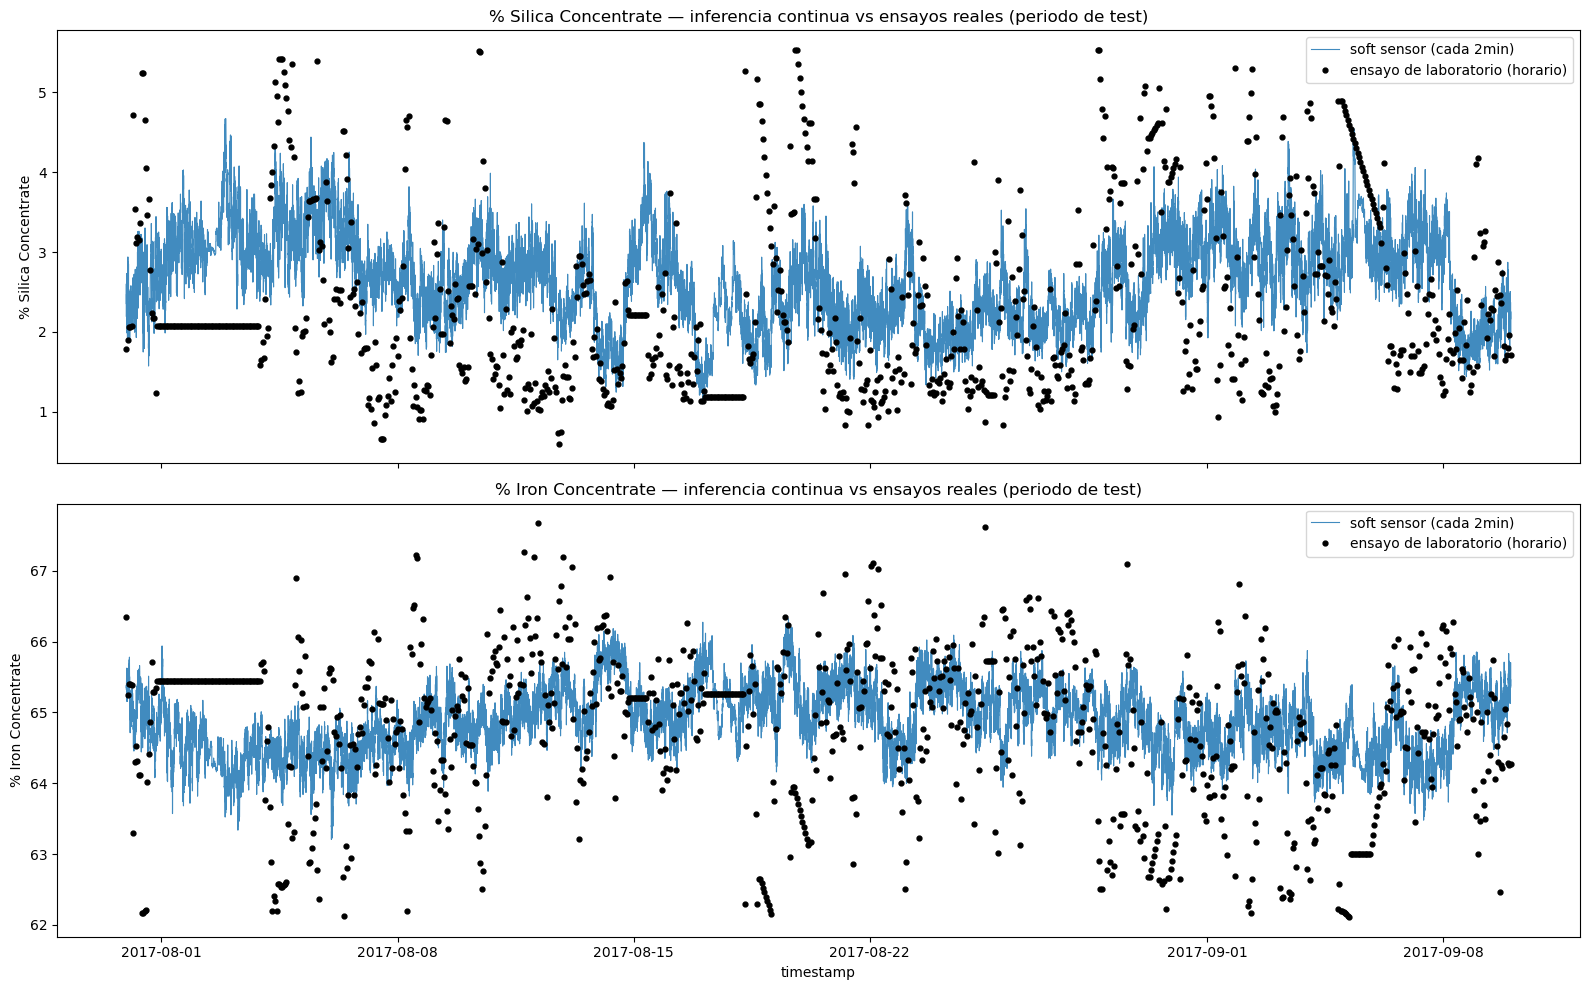


cambio medio de la prediccion entre instantes consecutivos:
  % Silica Concentrate   0.1394   (std del target: 1.1261)
  % Iron Concentrate     0.1229   (std del target: 1.1136)


In [21]:
# ---------------------------------------------------------------------------
# Parte 2, celda 6: la prueba de despliegue.
# Entrenado con ~3.900 ensayos horarios, evaluado CADA 2 MINUTOS sobre el tramo
# de test. Misma funcion de features, anclada a "ahora" en vez de al ensayo.
# ---------------------------------------------------------------------------
modelo_deploy = {}
for tgt in TARGETS:
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(train[FEATCOLS].values, train[tgt].values)
    modelo_deploy[tgt] = m

# Rejilla continua de inferencia: TODAS las filas de 2 min del periodo de test,
# no solo las que coinciden con un ensayo.
F_test = F[(F.index > test.index.min()) & (F.index <= test.index.max())].dropna()
print(f'instantes de inferencia (cada {RESAMPLE}): {len(F_test):,}')
print(f'ensayos de laboratorio en el mismo periodo: {len(test):,}')
print(f'-> el sensor emite {len(F_test) / len(test):.0f}x mas lecturas que el laboratorio')

salida = pd.DataFrame(index=F_test.index)
for tgt in TARGETS:
    salida[tgt] = modelo_deploy[tgt].predict(F_test[FEATCOLS].values)

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(16, 5 * len(TARGETS)), sharex=True)
for ax, tgt in zip(np.atleast_1d(axes), TARGETS):
    ax.plot(salida.index, salida[tgt], lw=0.8, alpha=0.85,
            label=f'soft sensor (cada {RESAMPLE})')
    ax.plot(test.index, test[tgt], 'o', ms=3.5, color='black',
            label='ensayo de laboratorio (horario)')
    ax.set_title(f'{tgt} — inferencia continua vs ensayos reales (periodo de test)')
    ax.set_ylabel(tgt); ax.legend(loc='upper right')
axes[-1].set_xlabel('timestamp') if len(TARGETS) > 1 else None
plt.tight_layout(); plt.show()

# ¿Es estable la salida continua, o oscila sin sentido entre ensayos?
paso = salida.diff().abs().mean()
print('\ncambio medio de la prediccion entre instantes consecutivos:')
for tgt in TARGETS:
    print(f'  {tgt:22s} {paso[tgt]:.4f}   (std del target: {lab[tgt].std():.4f})')

## Como leer estos resultados

**El numero que importa es `mejora_pct_vs_persist`.** Positivo = el modelo aporta algo
sobre no hacer nada; negativo = la persistencia gana y el modelo no se despliega.

Que espera cada configuracion responder:

- **1 vs 2** — ¿aporta la dinamica *dentro* de la ventana (std, pendiente, min/max)
  sobre el simple nivel medio? Esta es exactamente la pregunta de si merece la pena
  conservar el detalle sub-horario. `main.ipynb` (celdas 69-74) ya respondio que no por
  varias vias; aqui se comprueba sobre este pipeline concreto y sin fuga.
- **2 vs 3** — ¿aportan los retardos de 1-3 h? Es la hipotesis fisica del tiempo de
  residencia, y a priori la mas prometedora: el techo esta hacia arriba en la escala
  temporal, no hacia abajo.
- **4** — el sistema realmente desplegable. Combina proceso + ultimo ensayo.

**Si todas las configuraciones quedan por debajo de la persistencia**, la conclusion no
es que el trabajo haya fallado: es que las 21 variables de proceso, a esta resolucion,
no contienen informacion sobre el concentrado mas alla de su propia inercia horaria —
y ese es un resultado real, medido sobre un split que no puede hacer trampa. El R² de
0.94 de la parte 1 no era una alternativa mejor: era el mismo problema con la respuesta
copiada en el conjunto de test.

**Sobre el despliegue por minuto** (celda 6): el modelo se entrena con ~3.900 ejemplos
horarios pero emite ~30 lecturas por hora. Eso es legitimo porque las features son de
ventana movil. Lo que la salida continua representa es el **estado del proceso** entre
ensayos, no medidas de laboratorio inventadas. El cambio medio entre instantes
consecutivos, comparado con la std del target, indica si esa salida es suficientemente
estable para operar con ella o si habria que suavizarla antes de mostrarla en planta.